# 05 -- Gráficos e resultados

**GA033 · Módulo introdutório de programação científica**  
Autor: Diego Tavares Volpatto · Licença: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

Vamos transformar arrays em figuras que permitam comparar dados e reconhecer erros.
O exemplo é a função conhecida $u(x)=x(1-x)$ em $[0,1]$; vamos amostrá-la e
interpolar seus valores. **Não estamos resolvendo uma EDP pelo método de elementos finitos.**

Pré-requisitos: funções e arrays NumPy, dos cadernos 03 e 04.
Ao final, você deverá distinguir curva de referência, amostras, interpolação e erro,
e construir uma figura com eixos, legenda e escala compreensíveis.

Percurso: dados → figura → comparação → medida de erro → exercícios → exportação opcional.
Execute de cima para baixo; ao terminar, use **Restart Kernel and Run All**.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## Preparar os dados antes de desenhar

A função abaixo aceita tanto um número quanto um array. Usaremos 9 amostras e
uma malha densa para desenhar a referência. As variáveis deste exemplo são
**adimensionais**; não vamos inventar uma unidade física para os eixos.


In [2]:
def funcao_referencia(x):
    return x * (1.0 - x)


x_amostras = np.linspace(0.0, 1.0, 9)
u_amostras = funcao_referencia(x_amostras)
x_denso = np.linspace(0.0, 1.0, 1601)
u_referencia = funcao_referencia(x_denso)
print(f"Amostras: {x_amostras.size}; pontos para desenhar: {x_denso.size}")

Amostras: 9; pontos para desenhar: 1601


## Uma figura e um sistema de eixos

`fig` representa a figura; `ax` representa o sistema de eixos onde colocamos os dados.
Usar esses objetos deixa explícito **qual gráfico** estamos modificando.
A linha usa muitos pontos para mostrar a forma da função; os marcadores mostram
somente os valores amostrados.


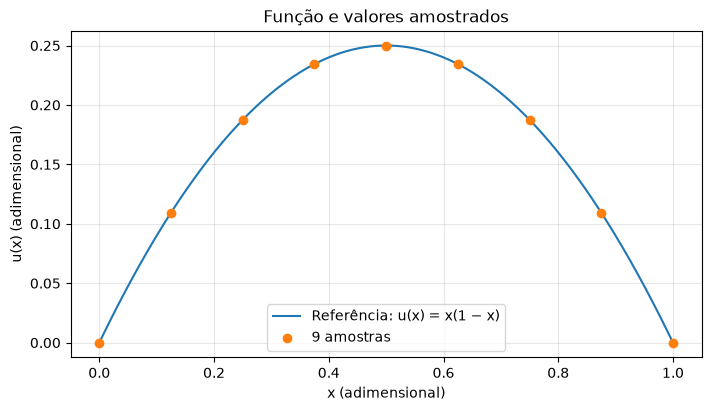

In [3]:
fig_curva, ax_curva = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax_curva.plot(
    x_denso, u_referencia, color="tab:blue", label="Referência: u(x) = x(1 − x)"
)
ax_curva.scatter(
    x_amostras, u_amostras, color="tab:orange", zorder=3, label="9 amostras"
)
ax_curva.set(
    xlabel="x (adimensional)",
    ylabel="u(x) (adimensional)",
    title="Função e valores amostrados",
)
ax_curva.grid(alpha=0.3)
ax_curva.legend()
plt.show()

## Amostrar e interpolar são operações diferentes

Amostramos ao calcular a função nos pontos escolhidos. Ao unir pontos vizinhos
por segmentos de reta, construímos uma **interpolação linear**.
`np.interp` avalia essa interpolação nos pontos de `x_denso`; aqui todos eles estão
no intervalo coberto pelas amostras.


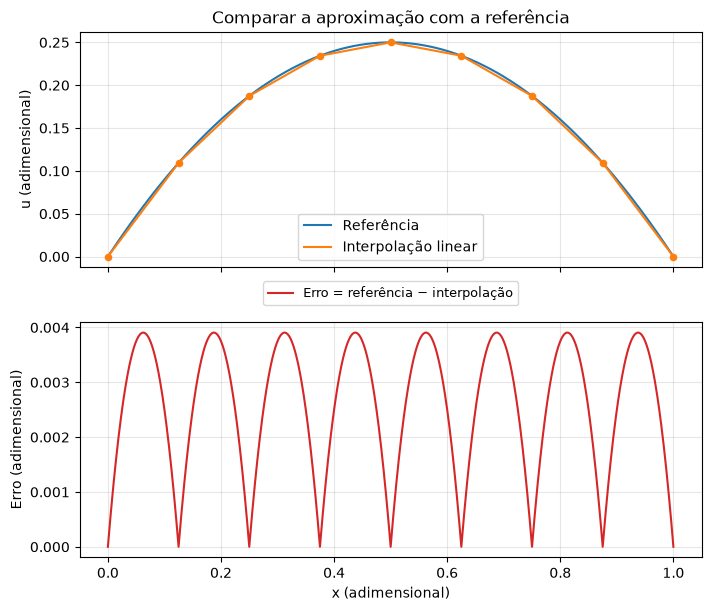

In [4]:
u_interpolada = np.interp(x_denso, x_amostras, u_amostras)
erro = u_referencia - u_interpolada

fig_comparacao, eixos = plt.subplots(
    2, 1, figsize=(7, 6), sharex=True, constrained_layout=True
)
eixos[0].plot(x_denso, u_referencia, label="Referência", color="tab:blue")
eixos[0].plot(x_denso, u_interpolada, label="Interpolação linear", color="tab:orange")
eixos[0].scatter(x_amostras, u_amostras, color="tab:orange", s=20, zorder=3)
eixos[0].set(ylabel="u (adimensional)", title="Comparar a aproximação com a referência")
eixos[1].plot(x_denso, erro, color="tab:red", label="Erro = referência − interpolação")
eixos[1].set(xlabel="x (adimensional)", ylabel="Erro (adimensional)")
for ax in eixos:
    ax.grid(alpha=0.3)
eixos[0].legend()
eixos[1].legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), fontsize=9)
plt.show()

O erro se anula nos nós porque usamos os valores da referência para interpolar.
Isso **não** significa que as duas funções coincidam entre os nós. Os painéis
usam escalas verticais distintas para tornar o erro visível; leia os valores dos eixos.

## Do gráfico para uma medida de erro

Vamos calcular o maior erro **observado na malha densa** e aproximar a norma
$L^2$: $\|e\|_{L^2}=\sqrt{\int_0^1 e(x)^2\,dx}$.
`np.trapezoid` aproxima a integral pela regra dos trapézios.


In [5]:
erro_maximo_observado = np.max(np.abs(erro))
erro_l2_aproximado = np.sqrt(np.trapezoid(erro**2, x_denso))
norma_euclidiana_amostras = np.linalg.norm(erro)

print(f"Maior erro observado: {erro_maximo_observado:.6f}")
print(f"Norma L2 aproximada:  {erro_l2_aproximado:.6f}")
print(f"Norma do vetor:      {norma_euclidiana_amostras:.6f}")

Maior erro observado: 0.003906
Norma L2 aproximada:  0.002853
Norma do vetor:      0.114109


A norma do vetor e a norma da função representam objetos diferentes.
`np.linalg.norm(erro)` calcula a raiz da soma dos quadrados das entradas, sem o espaçamento da malha.
A integral leva em conta o intervalo. Não troque uma pela outra apenas porque
ambas usam quadrados e raiz quadrada.

Em geral, um máximo calculado em pontos discretos pode deixar passar um pico
entre eles. Aqui conhecemos a referência, mas esse cuidado continua importante
quando os dados vêm de uma simulação.


## Exercício 1 -- O que muda com mais amostras?

Antes de executar, preveja: passar de 9 para 17 amostras deve aumentar ou reduzir
o erro desta interpolação? A função auxiliar mantém fixa a malha de avaliação.
Altere `numero_pontos` na célula seguinte e compare os dois resultados.


In [6]:
def medir_erro_interpolacao(numero_pontos):
    x_nos = np.linspace(0.0, 1.0, numero_pontos)
    valores = funcao_referencia(x_nos)
    aproximacao = np.interp(x_denso, x_nos, valores)
    return np.max(np.abs(u_referencia - aproximacao))


numero_pontos = 9  # Experimente 17 e depois 5.
print(
    f"{numero_pontos} amostras: erro máximo observado = {medir_erro_interpolacao(numero_pontos):.6f}"
)

9 amostras: erro máximo observado = 0.003906


### Solução comentada do exercício 1

Neste exemplo suave, aumentar a quantidade de amostras uniformes reduz o erro.
Observe também a diferença entre **nós** e **intervalos**: 9 nós definem 8 intervalos.
Não conclua, a partir deste único experimento, que todo problema tem a mesma taxa de redução.


In [7]:
for numero_pontos in (5, 9, 17):
    erro_observado = medir_erro_interpolacao(numero_pontos)
    print(
        f"{numero_pontos:2d} nós | {numero_pontos - 1:2d} intervalos | erro = {erro_observado:.6f}"
    )

 5 nós |  4 intervalos | erro = 0.015625
 9 nós |  8 intervalos | erro = 0.003906
17 nós | 16 intervalos | erro = 0.000977


## Exercício 2 -- Comparar duas discretizações na mesma figura

A célula já desenha a referência e a interpolação com 5 nós. Acrescente uma
interpolação com 17 nós, diferenciando-a por cor e estilo de linha. Mantenha os
rótulos e a legenda. O código inicial funciona mesmo antes de você completar a atividade.


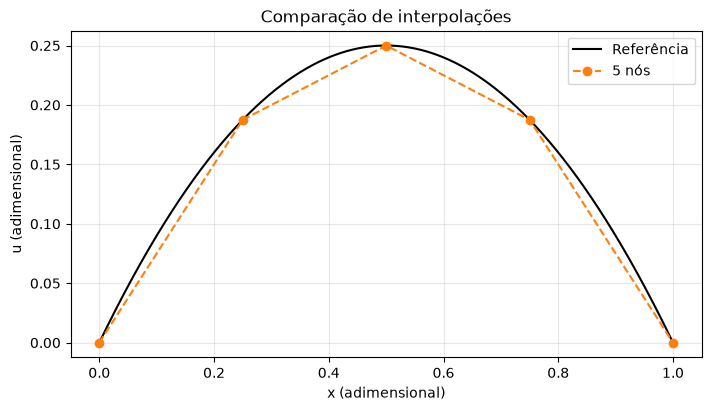

In [8]:
fig_exercicio, ax_exercicio = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax_exercicio.plot(x_denso, u_referencia, color="black", label="Referência")
x_cinco = np.linspace(0.0, 1.0, 5)
ax_exercicio.plot(
    x_cinco, funcao_referencia(x_cinco), "o--", color="tab:orange", label="5 nós"
)
# Sua tarefa: crie x_dezessete e acrescente outra chamada a ax_exercicio.plot(...).
ax_exercicio.set(
    xlabel="x (adimensional)",
    ylabel="u (adimensional)",
    title="Comparação de interpolações",
)
ax_exercicio.grid(alpha=0.3)
ax_exercicio.legend()
plt.show()

### Solução comentada do exercício 2

Passar as coordenadas e os valores diretamente a `plot` une os nós por segmentos
retos. Neste gráfico, não precisamos calcular `np.interp` antes de desenhar essas linhas.


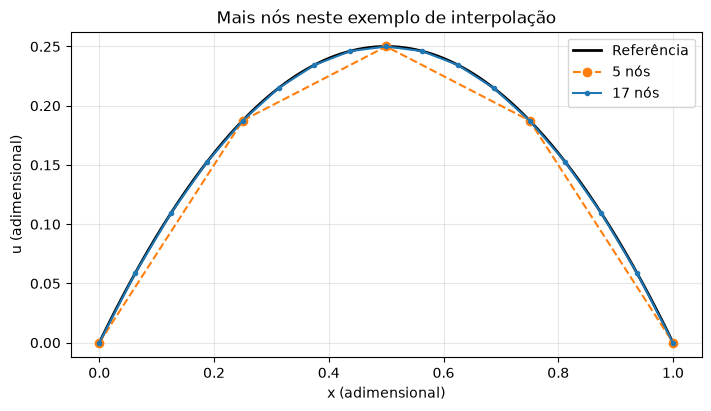

In [9]:
fig_solucao, ax_solucao = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax_solucao.plot(x_denso, u_referencia, color="black", linewidth=2, label="Referência")
for numero_pontos, estilo, cor in ((5, "o--", "tab:orange"), (17, ".-", "tab:blue")):
    x_nos = np.linspace(0.0, 1.0, numero_pontos)
    ax_solucao.plot(
        x_nos, funcao_referencia(x_nos), estilo, color=cor, label=f"{numero_pontos} nós"
    )
ax_solucao.set(
    xlabel="x (adimensional)",
    ylabel="u (adimensional)",
    title="Mais nós neste exemplo de interpolação",
)
ax_solucao.grid(alpha=0.3)
ax_solucao.legend()
plt.show()

## Exportação opcional, em uma pasta conhecida

O notebook não precisa salvar arquivos para funcionar. Se quiser exportar a
primeira figura, altere `salvar_figura` para `True`. O destino fica em `resultados/`
na raiz deste repositório, tanto ao iniciar pela raiz quanto por `notebooks/`.
O código não cria arquivos em outra pasta se não reconhecer essa estrutura.


In [10]:
salvar_figura = False
raiz = Path.cwd()
if raiz.name == "notebooks":
    raiz = raiz.parent

if salvar_figura:
    if not (raiz / "pixi.toml").is_file():
        raise RuntimeError(
            "Abra o notebook pela raiz do repositório ou pela pasta notebooks."
        )
    pasta_resultados = raiz / "resultados"
    pasta_resultados.mkdir(exist_ok=True)
    destino = pasta_resultados / "funcao-e-amostras.png"
    fig_curva.savefig(destino, dpi=160, bbox_inches="tight")
    print("Figura salva em resultados/funcao-e-amostras.png")
else:
    print("Exportação desativada: nenhum arquivo foi salvo.")

Exportação desativada: nenhum arquivo foi salvo.


## Erros comuns e como reconhecê-los

- Se os eixos não dizem o que está representado, o leitor precisa adivinhar.
- Se duas curvas coincidem visualmente, um gráfico do erro pode revelar a diferença.
- Se uma figura parece estranha, confira formas e valores dos arrays antes de mudar o estilo.
- Não dependa da ordem em que você clicou nas células: reinicie o kernel e execute tudo.

Extensão opcional: repita a interpolação para outra função suave e verifique se a
redução de erro se mantém. Uma observação numérica é evidência do caso testado,
não uma demonstração geral.


In [11]:
# As imagens já exibidas permanecem no notebook; fechamos os objetos de figura abertos.
plt.close("all")

## Para seguir

Você separou referência, amostras e aproximação; montou figuras com `fig, ax`;
e distinguiu uma norma de vetor de uma norma de função aproximada por quadratura.
No caderno 07, vamos organizar dados e operações em um módulo reutilizável.

Referências: [guia inicial do Matplotlib](https://matplotlib.org/stable/users/explain/quick_start.html),
[`numpy.interp`](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)
e [`numpy.trapezoid`](https://numpy.org/doc/stable/reference/generated/numpy.trapezoid.html).


[← Caderno anterior](04-arrays-com-numpy.ipynb) · [Índice do curso](../README.md) · [Próximo caderno →](06-calculo-cientifico-com-scipy.ipynb)

Autor: Diego Tavares Volpatto · [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/deed.pt-br)